In [43]:
import pandas as pd
import matplotlib.pyplot as plt


In [44]:
trades = pd.read_csv("../data/historical_data.csv")
sentiment = pd.read_csv("../data/fear_greed_index.csv")

In [45]:
print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


In [46]:
trades["date"] = pd.to_datetime(
    trades["Timestamp"],
    unit="ms"
).dt.normalize()

sentiment["date"] = pd.to_datetime(
    sentiment["date"]
).dt.normalize()

print("\nTrade Date Range:")
print(trades["date"].min())
print(trades["date"].max())

print("\nSentiment Date Range:")
print(sentiment["date"].min())
print(sentiment["date"].max())


Trade Date Range:
2023-03-28 00:00:00
2025-06-15 00:00:00

Sentiment Date Range:
2018-02-01 00:00:00
2025-05-02 00:00:00


In [47]:
merged = pd.merge(
    trades,
    sentiment[["date", "classification"]],
    on="date",
    how="left"
)

print("\nMerged Shape:", merged.shape)

print("\nMissing Classifications:")
print(merged["classification"].isna().sum())

print("\nSentiment Distribution:")
print(merged["classification"].value_counts())


Merged Shape: (211224, 18)

Missing Classifications:
26961

Sentiment Distribution:
classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64


In [48]:
avg_pnl = merged.groupby(
    "classification"
)["Closed PnL"].mean()

print("\nAverage PnL:")
print(avg_pnl)


Average PnL:
classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64


In [49]:
total_pnl = merged.groupby(
    "classification"
)["Closed PnL"].sum()

print("\nTotal PnL:")
print(total_pnl)


Total PnL:
classification
Extreme Greed    1.769655e+05
Fear             6.699925e+06
Greed            3.189617e+06
Neutral          1.587424e+05
Name: Closed PnL, dtype: float64


WIN RATE

In [50]:
merged["win"] = merged["Closed PnL"] > 0

win_rate = (
    merged.groupby("classification")["win"]
    .mean() * 100
)

print("\nWin Rate (%):")
print(win_rate)



Win Rate (%):
classification
Extreme Greed    49.008905
Fear             41.514592
Greed            44.647138
Neutral          31.718247
Name: win, dtype: float64


In [51]:
volume = merged.groupby(
    "classification"
)["Size USD"].sum()

print("\nVolume:")
print(volume)


Volume:
classification
Extreme Greed    3.940677e+07
Fear             7.041585e+08
Greed            1.155037e+08
Neutral          2.184323e+07
Name: Size USD, dtype: float64


In [52]:
top_coins = (
    merged.groupby("Coin")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop Coins:")
print(top_coins)


Top Coins:
Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


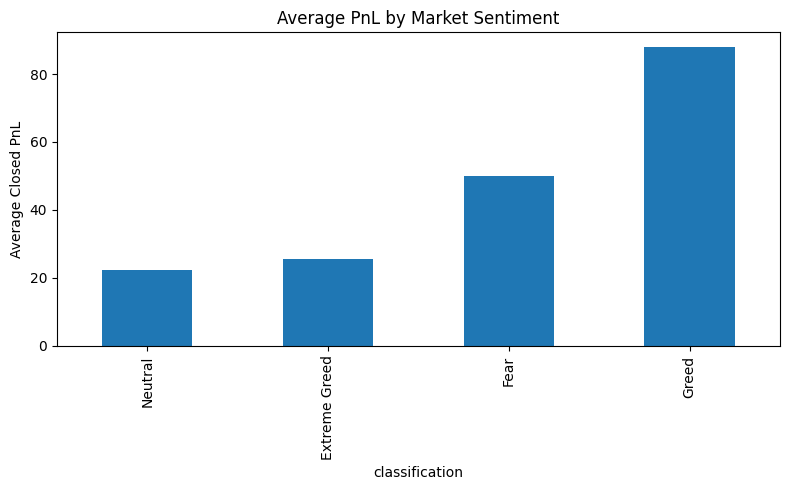

In [53]:
plt.figure(figsize=(8,5))
avg_pnl.sort_values().plot(kind="bar")
plt.title("Average PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.tight_layout()
plt.savefig("avg_pnl.png")
plt.show()

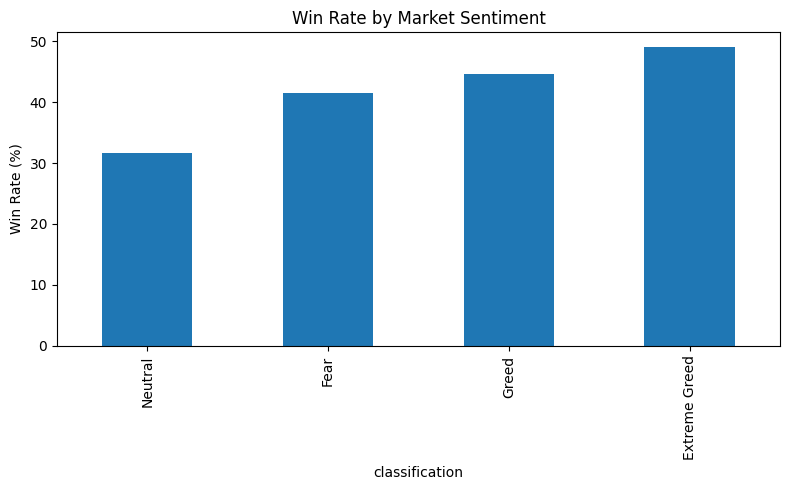

In [54]:
plt.figure(figsize=(8,5))
win_rate.sort_values().plot(kind="bar")
plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.tight_layout()
plt.savefig("win_rate.png")
plt.show()

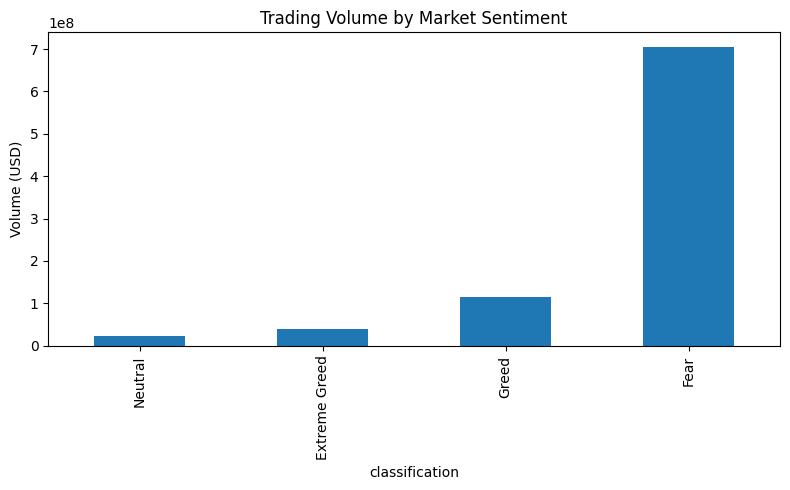

In [55]:
plt.figure(figsize=(8,5))
volume.sort_values().plot(kind="bar")
plt.title("Trading Volume by Market Sentiment")
plt.ylabel("Volume (USD)")
plt.tight_layout()
plt.savefig("volume.png")
plt.show()

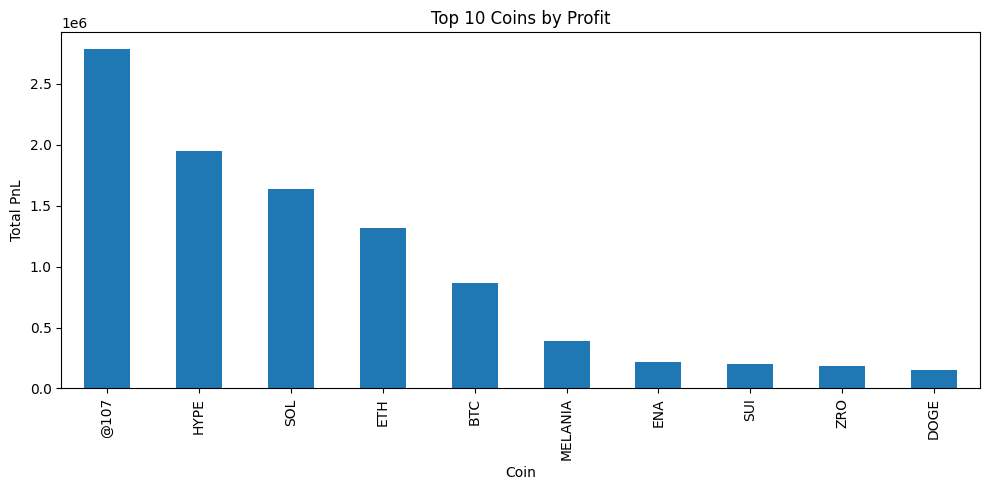

In [56]:
plt.figure(figsize=(10,5))
top_coins.plot(kind="bar")
plt.title("Top 10 Coins by Profit")
plt.ylabel("Total PnL")
plt.tight_layout()
plt.savefig("Top_coins.png")
plt.show()

In [57]:
summary = pd.DataFrame({
    "Average PnL": avg_pnl,
    "Win Rate (%)": win_rate,
    "Volume USD": volume
})

summary.to_csv("sentiment_analysis_results.csv")

print("\nAnalysis Complete!")


Analysis Complete!
